# Task Description:

Suppose we want to buy an apartment. We have \$100,000 available, and we can also take out a loan for an additional \$250,000, giving us a total budget of \$350,000. Let us create a model that will help predict whether an apartment with given characteristics can be purchased using only our own money (**cheap**), with a loan (**average**), or is beyond our financial reach (**expensive**).

Based on the available attributes, build a model that estimates whether a given property belongs to the class **cheap**, **average**, or **expensive**. You are provided with training data (`train_data.csv`) containing the original property prices (`SalePrice`) and a test set (`test_data.csv`).

The final results will be evaluated based on the average accuracy for each class. Please note that the classes are highly imbalanced! The file `evaluation.py` contains the function that will be used to calculate the performance of your model.

# Important!

Please carefully follow the instructions below and verify that your submitted solution complies with every point:

- Submit your solution through the MS Teams Assignment as a single `.zip` file containing: the code (either as a notebook or a `.py` script) and a `.csv` file with predictions generated for `test_data.csv`.
- Name the `.zip` file using the surnames and first names of both authors in ALPHABETICAL order. Additionally, the archive name must begin with the prefix `poniedzialek_`, `sroda_`, or `piatek_` (NOT shortened forms such as `pon`, `pia`, `śr`, or other variations).  
  Example: `sroda_MalyszAdam_SwiatekIga.zip`
- Name the prediction file `pred.csv`. The prediction file should contain exactly one column representing the predicted apartment price class (int):  
  `0: cheap`, `1: average`, `2: expensive`.  
  Please make sure that the format of your predictions is correct (the same number of predictions as elements in the test set, no headers, one column, etc.). An example `pred.csv` file in the expected format has been provided.
- Do not place files inside additional subfolders; they should be located directly inside the archive. Example structure of the `.zip` file:

```text
sroda_MalyszAdam_SwiatekIga.zip
├── pred.csv
└── solution.ipynb
```

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split


# Wczytanie danych i przygotowanie zbioru treningowego

<class 'pandas.DataFrame'>
RangeIndex: 4124 entries, 0 to 4123
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   SalePrice                  4124 non-null   int64  
 1   YearBuilt                  4124 non-null   int64  
 2   Size(sqf)                  4124 non-null   int64  
 3   Floor                      4124 non-null   int64  
 4   HallwayType                4124 non-null   str    
 5   HeatingType                4124 non-null   str    
 6   AptManageType              4124 non-null   str    
 7   N_Parkinglot(Ground)       4124 non-null   float64
 8   N_Parkinglot(Basement)     4124 non-null   float64
 9   TimeToBusStop              4124 non-null   str    
 10  TimeToSubway               4124 non-null   str    
 11  N_manager                  4124 non-null   float64
 12  N_elevators                4124 non-null   float64
 13  SubwayStation              4124 non-null   str    
 14  N_F

Text(0.5, 0, 'Class')

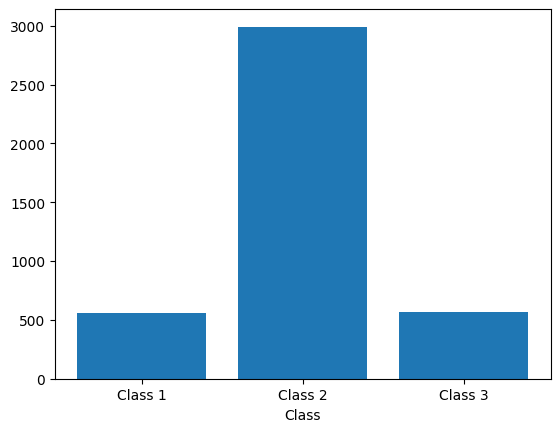

In [28]:
classes = [
    "SalePrice",
    "YearBuilt",
    "Size(sqf)",
    "Floor",
    "HallwayType",
    "HeatingType",
    "AptManageType",
    "N_Parkinglot(Ground)",
    "N_Parkinglot(Basement)",
    "TimeToBusStop",
    "TimeToSubway",
    "N_manager",
    "N_elevators",
    "SubwayStation",
    "N_FacilitiesInApt",
    "N_FacilitiesNearBy(Total)",
    "N_SchoolNearBy(Total)",
]


data = pd.read_csv("train_data.csv")

data.head()
data.info()

class1 = np.where(data["SalePrice"] <= 100000, 1, 0)
class2 = np.where((data["SalePrice"] > 100000) & (data["SalePrice"] <= 350000), 1, 0)
class3 = np.where(data["SalePrice"] > 350000, 1, 0)

data['Class'] = class1 * 0 + class2 * 1 + class3 * 2


data.head()
data.info()

class1_count = data['Class'].value_counts()[0]
class2_count = data['Class'].value_counts()[1]
class3_count = data['Class'].value_counts()[2]

plt.bar(['Class 1', 'Class 2', 'Class 3'], [class1_count, class2_count, class3_count])
plt.xlabel('Class')

# Data Preparation for Model

In [29]:
from sklearn.preprocessing import StandardScaler
X = data.drop(columns=['SalePrice', 'Class'])
y = data['Class']

X['YearBuilt'] = 2026 - X['YearBuilt'] # Transform year of construction to building age

categories = {
    'numerical': [
        'YearBuilt', 'Size(sqf)', 'Floor', 
        'N_Parkinglot(Ground)', 'N_Parkinglot(Basement)', 
        'N_manager', 'N_elevators', 'N_FacilitiesInApt', 
        'N_FacilitiesNearBy(Total)', 'N_SchoolNearBy(Total)'
    ],
    'ordinal': [
        'TimeToBusStop', 
        'TimeToSubway'
    ],
    'categorical': [
        'HallwayType', 
        'HeatingType', 
        'AptManageType', 
        'SubwayStation'
    ]
}

time_mapping = {
    '0~5min': 0, '0-5min': 0, 
    '5min~10min': 1, '10min~15min': 2, 
    '15min~20min': 3, 'no_subway_nearby': 4, 'no_bus_stop_nearby': 4
}

data['TimeToBusStop'] = data['TimeToBusStop'].map(time_mapping)
data['TimeToSubway'] = data['TimeToSubway'].map(time_mapping)

categorical_cols = ['HallwayType', 'HeatingType', 'AptManageType', 'SubwayStation']
data_encoded = pd.get_dummies(data, columns=categorical_cols)

X = data_encoded.drop(columns=['SalePrice', 'Class'])
y = data_encoded['Class']
X['YearBuilt'] = 2026 - X['YearBuilt']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Model

In [30]:
class HousePriceClassifier(torch.nn.Module):
    def __init__(self, input_size, hidden_size_1, hidden_size_2, num_classes):
        super(HousePriceClassifier, self).__init__()
        self.fc1 = torch.nn.Linear(input_size, hidden_size_1)
        self.relu1 = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(hidden_size_1, hidden_size_2)
        self.relu2 = torch.nn.ReLU()
        self.fc3 = torch.nn.Linear(hidden_size_2, num_classes)
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out

# Training

In [31]:
model = None
try:
    model = torch.load('house_price_classifier.pth')
    print("Model loaded successfully.")
except FileNotFoundError:
    print("Saved model not found. A new model will be created.")
    model = HousePriceClassifier(input_size=X_train_scaled.shape[1], hidden_size_1=256, hidden_size_2=128, num_classes=3)
    target_counts = data['Class'].value_counts().sort_index()
    class_weights = 1.0 / target_counts
    class_weights = class_weights / class_weights.sum() * len(target_counts)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train.values, dtype=torch.long).to(device)
    class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float).to(device)

    criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(50000):
        model.train()
        optimizer.zero_grad()
        
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 50 == 0:
            preds = outputs.argmax(dim=1)
            unique, counts = torch.unique(preds, return_counts=True)
            print(f"Epoch [{epoch+1}/50000], Loss: {loss.item():.4f}, Predictions distribution: {dict(zip(unique.tolist(), counts.tolist()))}")

    torch.save(model.state_dict(), 'house_price_classifier.pth')

Saved model not found. A new model will be created.
Epoch [50/50000], Loss: 0.3179, Predictions distribution: {0: 776, 1: 1839, 2: 684}
Epoch [100/50000], Loss: 0.2693, Predictions distribution: {0: 738, 1: 1870, 2: 691}
Epoch [150/50000], Loss: 0.2578, Predictions distribution: {0: 737, 1: 1840, 2: 722}
Epoch [200/50000], Loss: 0.2508, Predictions distribution: {0: 736, 1: 1826, 2: 737}
Epoch [250/50000], Loss: 0.2460, Predictions distribution: {0: 737, 1: 1822, 2: 740}
Epoch [300/50000], Loss: 0.2424, Predictions distribution: {0: 737, 1: 1827, 2: 735}
Epoch [350/50000], Loss: 0.2395, Predictions distribution: {0: 735, 1: 1838, 2: 726}
Epoch [400/50000], Loss: 0.2377, Predictions distribution: {0: 711, 1: 1869, 2: 719}
Epoch [450/50000], Loss: 0.2348, Predictions distribution: {0: 715, 1: 1857, 2: 727}
Epoch [500/50000], Loss: 0.2331, Predictions distribution: {0: 722, 1: 1846, 2: 731}
Epoch [550/50000], Loss: 0.2313, Predictions distribution: {0: 711, 1: 1873, 2: 715}
Epoch [600/500

# Evaluation on Test Set

In [32]:
test_frame = pd.read_csv("test_data.csv")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

test_frame['TimeToBusStop'] = test_frame['TimeToBusStop'].map(time_mapping)
test_frame['TimeToSubway'] = test_frame['TimeToSubway'].map(time_mapping)
test_frame['YearBuilt'] = 2026 - test_frame['YearBuilt']

test_encoded = pd.get_dummies(test_frame, columns=categorical_cols)
test_encoded = test_encoded.reindex(columns=X.columns, fill_value=0)

X_test_scaled = scaler.transform(test_encoded)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    test_preds = test_outputs.argmax(dim=1).cpu().numpy()

pd.DataFrame(test_preds).to_csv("pred.csv", index=False, header=False)
print("pred.csv file generated successfully.")

pred.csv file generated successfully.
